In [1]:
import copy
import numpy
import pandas
import subprocess

from matplotlib import pyplot

from file_services import fasta_file_service
from gffutils      import load_gff

def abundance_comparison_plot(abundance_a: pandas.DataFrame,
                          abundance_b: pandas.DataFrame,
                          show: str,
                          axes) -> None:
    """
    Plots a comparison of expression profiles

    Args:
        abundance_before (pandas.DataFrame): 
        abundance_after (pandas.DataFrame): 
        show (str): counts or tpm
        axes
    """

    x = abundance_a[show]
    y = abundance_b[show]
    m = numpy.max([int(numpy.max(x)),int(numpy.max(y))])

    # General formatting
    axes.set_xscale("log")
    axes.set_yscale("log")
    axes.set_xlim(xmin=0.001,xmax=m)
    axes.set_ylim(ymin=0.001,ymax=m)

    # Plotting
    axes.scatter(x, y, s=1, color="black")
    axes.plot([0,m],[0,m], color="red")

# A benchmark dataset of chr1 mouse reads

In this notebook:
1. Filtering Illumina RNAseq short reads for reads from chromosome 1 transcripts
2. Creating an expression profile for the simulation of matching chromosome 1 nanopore reads

**Required tools:**

- [MapSampler](https://github.com/SimonHegele/MapSampler)
- [Kallisto](https://github.com/pachterlab/kallisto)

**Required non-built-in libraries:**

- numpy
- pandas
- matplotlib 

- file_services (own creation, should come with this notebook)

**Easy installation/usage:**

```
conda env create -n myenv -f environment.yml
git clone https://www.github.com/SimonHegele/MapSampler
cd MapSampler
conda activate myenv
pip install .
```

Run the notebook from the created environment.

**Multi-threading:**

Set the number of threads you want to use here:

In [2]:
threads = 8

## 1 Creating a reference that only contains chr1 chromosomes

Here, pandas is used to load the GRCm39 annotation and filter for transcripts originating
from chromosome 1.

### 1.1 Retrieving transcript IDs from the GFF-file

In [3]:
gff  = load_gff("./genomic.gff")
gff  = gff.loc[gff["type"].str.contains("RNA", na=False) & (gff["seqname"]=="NC_000067.7")]
IDs  = [s.split(";")[0][7:] for s in list(gff["attributes"]) if s.startswith("ID=rna")]

display(gff)

,seqname,source,type,start,end,score,strand,frame,attributes
2,NC_000067.7,cmsearch,snRNA,3172239,3172348,.,+,.,ID=rna-XR_004936710.1;Parent=gene-Gm26206;Dbxr...
5,NC_000067.7,Gnomon,mRNA,3269956,3741733,.,-,.,ID=rna-XM_006495550.5;Parent=gene-Xkr4;Dbxref=...
13,NC_000067.7,BestRefSeq,mRNA,3284705,3741721,.,-,.,ID=rna-NM_001011874.1;Parent=gene-Xkr4;Dbxref=...
20,NC_000067.7,Gnomon,mRNA,3393039,3741733,.,-,.,ID=rna-XM_011238395.4;Parent=gene-Xkr4;Dbxref=...
27,NC_000067.7,Gnomon,mRNA,3420932,3741733,.,-,.,ID=rna-XM_036152287.1;Parent=gene-Xkr4;Dbxref=...
...,...,...,...,...,...,...,...,...,...
210409,NC_000067.7,Gnomon,mRNA,194819555,194859096,.,-,.,ID=rna-XM_006497225.4;Parent=gene-Cr2;Dbxref=G...
210447,NC_000067.7,Gnomon,mRNA,194819555,194858956,.,-,.,ID=rna-XM_006497224.4;Parent=gene-Cr2;Dbxref=G...
210491,NC_000067.7,Gnomon,mRNA,194819555,194858918,.,-,.,ID=rna-XM_006497222.4;Parent=gene-Cr2;Dbxref=G...
210543,NC_000067.7,Gnomon,mRNA,194819555,194850725,.,-,.,ID=rna-XM_017314050.3;Parent=gene-Cr2;Dbxref=G...


### 1.2 Creating a FASTA-file with chromosome 1 transcripts

In [4]:
file_service     = fasta_file_service.FastaFileService()
transcripts      = list(file_service.read("rna.fna"))
IDs_copy         = copy.copy(IDs)                                                       
transcripts_chr1 = []

for t in transcripts:
    if t["header"].split(" ")[0][1:] in IDs_copy:
        transcripts_chr1.append(t)
        IDs_copy.remove(t["header"].split(" ")[0][1:])

file_service.write("chr1_transcripts.fasta", transcripts_chr1)

## 2. Filtering short reads

Short reads are filtered using MapSampler by mapping the Short reads by mapping them to the chromosome reference transcripts.

In [5]:
subprocess.run(["mapsampler",
                "-m", "sr",
                "-ql", "short_1.fastq",
                "-qr", "short_2.fastq",
                "-t", str(threads),
                "chr1_transcripts.fasta"],
                check=True)

24-07-2025 14:03:04 INFO Splitting query file(s) ...
24-07-2025 14:07:06 INFO Indexing reference ...


[M::mm_idx_gen::1.103*0.96] collected minimizers
[M::mm_idx_gen::1.204*1.46] sorted minimizers
[M::main::1.336*1.41] loaded/built the index for 7717 target sequence(s)
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::mm_idx_stat::1.357*1.40] distinct minimizers: 1360613 (42.12% are singletons); average occurrences: 4.248; average spacing: 6.007; total length: 34718461
[M::main] Version: 2.28-r1209
[M::main] CMD: minimap2 -x sr -t 8 -d ms_tmp_24d07m2025y_14h03m04s/reference.mm2idx chr1_transcripts.fasta
[M::main] Real time: 1.368 sec; CPU: 1.916 sec; Peak RSS: 0.261 GB


24-07-2025 14:07:07 INFO Mapping ...


[M::main::0.167*1.00] loaded/built the index for 7717 target sequence(s)
[M::mm_mapopt_update::0.168*1.00] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::main::0.173*1.00] loaded/built the index for 7717 target sequence(s)
[M::mm_mapopt_update::0.173*1.00] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::main::0.176*1.00] loaded/built the index for 7717 target sequence(s)
[M::mm_mapopt_update::0.177*1.00] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::main::0.174*1.01] loaded/built the index for 7717 target sequence(s)
[M::mm_mapopt_update::0.174*1.01] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::main::0.186*0.95] loaded/built the index for 7717 target sequence(s)
[M::mm_mapopt_update::0.186*0.95] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::main::0.186*1.00] loaded/built the index for 7717 target sequence(

24-07-2025 14:10:11 INFO Start filtering ... 
24-07-2025 14:10:11 INFO Starting 16 threads (8 at a time)
24-07-2025 14:10:11 INFO Thread   0 started
24-07-2025 14:10:11 INFO Thread   1 started
24-07-2025 14:10:11 INFO Thread   2 started
24-07-2025 14:10:11 INFO Thread   3 started
24-07-2025 14:10:11 INFO Thread   5 started
24-07-2025 14:10:11 INFO Thread   6 started
24-07-2025 14:10:11 INFO Thread   7 started
24-07-2025 14:10:11 INFO Thread   4 started
24-07-2025 14:12:17 INFO Thread   6 done
24-07-2025 14:12:18 INFO Thread   8 started
24-07-2025 14:12:18 INFO Thread   5 done
24-07-2025 14:12:18 INFO Thread   4 done
24-07-2025 14:12:19 INFO Thread   9 started
24-07-2025 14:12:19 INFO Thread  10 started
24-07-2025 14:12:20 INFO Thread   0 done
24-07-2025 14:12:20 INFO Thread  11 started
24-07-2025 14:12:24 INFO Thread   1 done
24-07-2025 14:12:24 INFO Thread   2 done
24-07-2025 14:12:24 INFO Thread  12 started
24-07-2025 14:12:24 INFO Thread  13 started
24-07-2025 14:12:24 INFO Thread  

CompletedProcess(args=['mapsampler', '-m', 'sr', '-ql', 'short_1.fastq', '-qr', 'short_2.fastq', '-t', '8', 'chr1_transcripts.fasta'], returncode=0)

In [6]:
subprocess.run(["mv", "short_1.fastq.ms", "chr1_short_1.fastq"], check=True)
subprocess.run(["mv", "short_2.fastq.ms", "chr1_short_2.fastq"], check=True)

CompletedProcess(args=['mv', 'short_2.fastq.ms', 'chr1_short_2.fastq'], returncode=0)

## 2. Generating an expression profile for chr1 transcripts

To generate long reads with abundances matching those of the short reads, NanoSim requires an expression profile. This also provides the oppurtunity to evaluate the success of the short read filtering.

### 2.1 Abundance estimation with Kallisto

In [8]:
# Index construction
subprocess.run(["kallisto","index","-t",str(threads),"-i","rna.idx","rna.fna"], check=True)

# Quantification
subprocess.run(["kallisto","quant","-t",str(threads),"-i","rna.idx","-o","kallisto_all",  "short_1.fastq",      "short_2.fastq"],      check=True)
subprocess.run(["kallisto","quant","-t",str(threads),"-i","rna.idx","-o","kallisto_chr1", "chr1_short_1.fastq", "chr1_short_2.fastq"], check=True)


[build] loading fasta file rna.fna
[build] k-mer length: 31
[build] warning: clipped off poly-A tail (longer than 10)
        from 10211 target sequences
[build] warning: replaced 30 non-ACGUT characters in the input sequence
        with pseudorandom nucleotides


KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Finished
CompactedDBG::build(): Estimated number of k-mers occurring at least once: 123737229
CompactedDBG::build(): Estimated number of minimizer occurring at least once: 30662041
CompactedDBG::filter(): Processed 516666991 k-mers in 134700 reads
CompactedDBG::filter(): Found 123932345 unique k-mers
CompactedDBG::filter(): Number of blocks in Bloom filter is 845861
CompactedDBG::construct(): Extract approximate unitigs (1/2)
CompactedDBG::construct(): Extract approximate unitigs (2/2)
CompactedDBG::construct(): Closed all input files

CompactedDBG::construct(): Splitting unitigs (1/2)

CompactedDBG::construct(): Splitting unitigs (2/2)
CompactedDBG::construct(): Before split: 622656 unitigs
CompactedDBG::construct(): After split (1/1): 622656 unitigs
CompactedDBG::construct(): Unitigs split: 1346
Compacted

[build] building MPHF
[build] creating equivalence classes ... 
[build] target de Bruijn graph has k-mer length 31 and minimizer length 23
[build] target de Bruijn graph has 555272 contigs and contains 124043958 k-mers 


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 134,700
[index] number of k-mers: 124,043,958
[quant] running in paired-end mode
[quant] will process pair 1: short_1.fastq
                             short_2.fastq
[progress] 57M reads processed (82.3% mapped)              done
[quant] processed 58,219,222 reads, 47,944,642 reads pseudoaligned
[quant] estimated average fragment length: 157.7
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 1,412 rounds


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 134,700
[index] number of k-mers: 124,043,958
[quant] running in paired-end

CompletedProcess(args=['kallisto', 'quant', '-t', '8', '-i', 'rna.idx', '-o', 'kallisto_chr1', 'chr1_short_1.fastq', 'chr1_short_2.fastq'], returncode=0)

### 2.2 Evaluation of the short read filtering

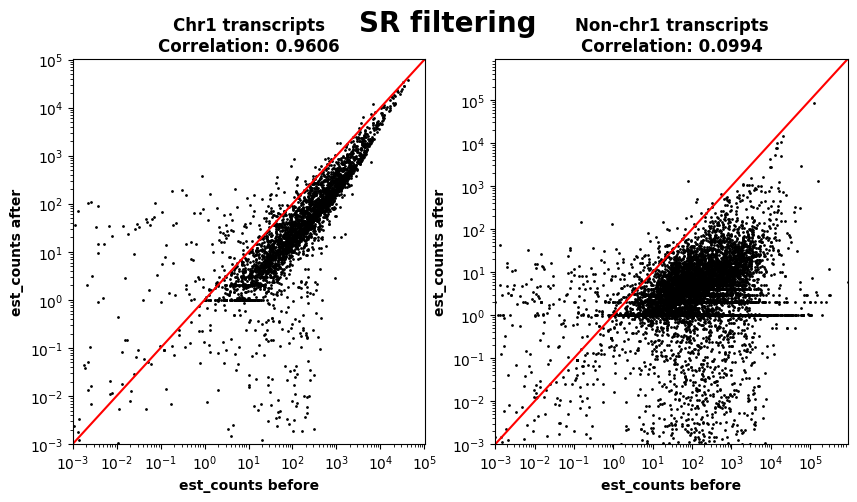

In [9]:
sr_abundance_unfiltered        = pandas.read_csv("kallisto_all/abundance.tsv", sep="\t")
sr_abundance_filtered          = pandas.read_csv("kallisto_chr1/abundance.tsv", sep="\t")
sr_abundance_unfiltered_chr1   = sr_abundance_unfiltered.loc[sr_abundance_unfiltered["target_id"].isin(IDs)]
sr_abundance_filtered_chr1     = sr_abundance_filtered.loc[sr_abundance_unfiltered["target_id"].isin(IDs)]
sr_abundance_unfiltered_nchr1  = sr_abundance_unfiltered.loc[~sr_abundance_unfiltered["target_id"].isin(IDs)]
sr_abundance_filtered_nchr1    = sr_abundance_filtered.loc[~sr_abundance_unfiltered["target_id"].isin(IDs)]

show = "est_counts"

sr_correlation_chr1  = numpy.corrcoef(sr_abundance_filtered_chr1[show],  sr_abundance_unfiltered_chr1[show])[0,1]
sr_correlation_nchr1 = numpy.corrcoef(sr_abundance_filtered_nchr1[show], sr_abundance_unfiltered_nchr1[show])[0,1]

fig, axes = pyplot.subplots(1,2,figsize=(10,5))
fig.suptitle("SR filtering", fontweight="bold", fontsize=20)
for i in range(2):
    axes[i].set_xlabel(f"{show} before", fontweight="bold")
    axes[i].set_ylabel(f"{show} after",  fontweight="bold")
axes[0].set_title(f"Chr1 transcripts\nCorrelation: {round(sr_correlation_chr1,4)}", fontweight="bold")
axes[1].set_title(f"Non-chr1 transcripts\nCorrelation: {round(sr_correlation_nchr1,4)}", fontweight="bold")

abundance_comparison_plot(sr_abundance_unfiltered_chr1, sr_abundance_filtered_chr1, show, axes[0])
abundance_comparison_plot(sr_abundance_unfiltered_nchr1, sr_abundance_filtered_nchr1, show, axes[1])

### 2.3 Setting abundance of non-chromosome transcript to 0

The above plots show that the filtering process was successfull.<br>
1. Transcript counts for chr1 transcripts are almost identical.
2. Transcript counts for non-chr1 transcripts are greatly reduced.

However, there still are non-chr1 transcripts with non-zero counts / tpm.
Those are set to zero to only simulate chr1 long reads.

In [10]:
chr1_abundance = sr_abundance_filtered.copy()

for i, row in chr1_abundance.iterrows():
    if not row["target_id"] in IDs:
        chr1_abundance.iloc[i,3] = 0
        chr1_abundance.iloc[i,4] = 0

## 3. Long read simulation with NanoSim

### 3.1. Preparing files

There are two issues with NanoSim that need to be addressed before we can use it: 

1. NanoSim only able to read expression files with exactly three rows
2. NanoSim can not handle Transcript-IDs containing underscores (see: https://github.com/bcgsc/NanoSim/issues/237)

In [11]:
chr1_abundance = chr1_abundance.drop(["length","eff_length"],axis=1)

for i in range(len(chr1_abundance)):
    chr1_abundance.iloc[i,0] = chr1_abundance.iloc[i,0].replace("_","")
    
display(chr1_abundance)

chr1_abundance.to_csv("expression.tsv", sep="\t", index=False)

,target_id,est_counts,tpm
0,NM001001130.3,0.0,0.0
1,NM001001144.3,0.0,0.0
2,NM001001152.2,0.0,0.0
3,NM001001160.3,0.0,0.0
4,NM001001176.2,0.0,0.0
...,...,...,...
134695,XR882648.2,0.0,0.0
134696,XR882649.3,0.0,0.0
134697,XR882650.3,0.0,0.0
134698,XR882651.1,0.0,0.0
